In [4]:
"""
plot_cesm_era5_lhflux_pdf.py

Reads surface latent heat flux (daily lat-lon) from:
 - two CESM cases (multiple files each)
 - one ERA5 file (single file)
Selects a region (default: West Pacific)
and plots the probability density functions (PDFs) across all grid values.

Dependencies:
    xarray, numpy, matplotlib
"""

import xarray as xr
import numpy as np
import glob as glob
import matplotlib.pyplot as plt
from typing import List, Tuple, Optional

In [5]:
from dask.distributed import Client
from ncar_jobqueue import NCARCluster

/glade/u/apps/opt/conda/envs/npl-2025b/lib/python3.12/site-packages/ncar_jobqueue/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [6]:
cluster = NCARCluster(project='P93300642',interface='ext',walltime="12:00:00")
cluster
cluster.scale(jobs=8)
client = Client(cluster)
client

/glade/u/apps/opt/conda/envs/npl-2025b/lib/python3.12/site-packages/dask_jobqueue/core.py:266: FutureWarning: job_extra has been renamed to job_extra_directives. You are still using it (even if only set to []; please also check config files). If you did not set job_extra_directives yet, job_extra will be respected for now, but it will be removed in a future release. If you already set job_extra_directives, job_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/glade/u/apps/opt/conda/envs/npl-2025b/lib/python3.12/site-packages/dask_jobqueue/core.py:285: FutureWarning: env_extra has been renamed to job_script_prologue. You are still using it (even if only set to []; please also check config files). If you did not set job_script_prologue yet, env_extra will be respected for now, but it will be removed in a future release. If you already set job_script_prologue, env_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/glade/u/apps/opt/con

Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/Compute/proxy/37341/status,
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/Compute/proxy/37341/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://128.117.208.173:41135,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/Compute/proxy/37341/status,Total threads: 0
Started: Just now,Total memory: 0 B


['/glade/derecho/scratch/hannay/archive/b.e30_alpha07g.BHISTC_LTso.ne30_t232_wgx3.271/atm/hist/b.e30_alpha07g.BHISTC_LTso.ne30_t232_wgx3.271.cam.h2a.199*']
['/glade/campaign/cgd/cesm/CESM2-LE/atm/proc/tseries/day_1//PRECT/b.e21.BHISTcmip6.f09_g17.LE2-1001.001.cam.h1.PRECT.19900101-19991231.nc']
Loading CESM case 1...
Loading CESM case 2...
Loading TRMM data...


/glade/derecho/scratch/rneale/tmp/ipykernel_67799/275390921.py:17: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 365. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_mfdataset(file_list, combine="by_coords", chunks=chunks, engine="netcdf4")
/glade/derecho/scratch/rneale/tmp/ipykernel_67799/275390921.py:24: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds =

<xarray.DataArray 'PRECT' (time: 4383, lat: 99, lon: 360)> Size: 625MB
[156210120 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 35kB 1998-01-01 1998-01-02 ... 2009-12-31
  * lat      (lat) float64 792B -48.0 -47.02 -46.04 -45.06 ... 46.04 47.02 48.0
  * lon      (lon) float64 3kB -180.0 -179.0 -178.0 -177.0 ... 177.0 178.0 179.0
Attributes:
    units:       mm/day
    long_name:   total daily precipitation
    delta_t:     0000-00-00 03:00:00
    avg_period:  0000-00-00 01:00:00
    remap:       remapped via ESMF_regrid_with_weights: Conservative remapping

<xarray.DataArray 'PRECT' (time: 3660, lat: 16, lon: 17)> Size: 4MB
dask.array<getitem, shape=(3660, 16, 17), dtype=float32, chunksize=(20, 16, 17), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 128B 0.4712 1.414 2.356 3.298 ... 12.72 13.66 14.61
  * time     (time) object 29kB 1990-01-01 12:00:00 ... 2000-01-10 12:00:00
  * lon      (lon) float64 136B -105.0 -103.8 -102.5 ... -87.5 -86.25 -85.0
Attributes:
    units:         m/s
    long_name:     Total (convective and large-scale) precipitation rate (liq...
    cell_methods:  time: mean

CESM1 samples: 247,520, CESM2: 244,800, ERA5: 363,888


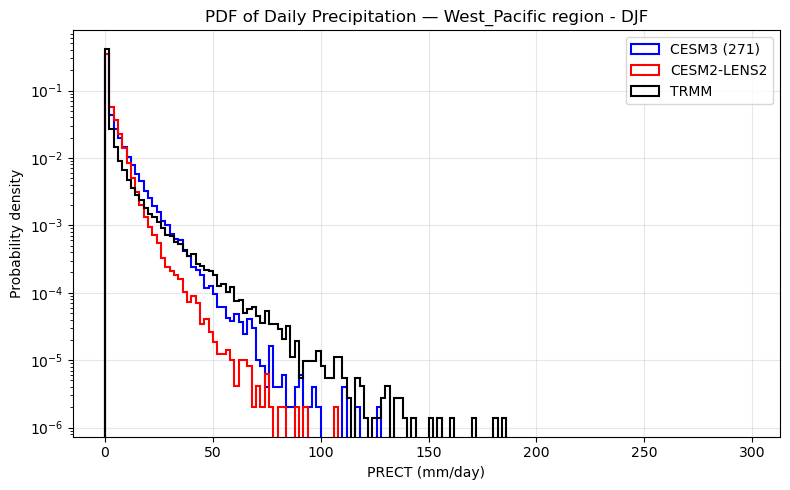

In [24]:
# --------------------------
# Helper functions
# --------------------------
def normalize_longitudes(ds, lon_name="lon"):
    """Convert 0–360° longitudes to −180–180° if needed."""
    lon = ds[lon_name]
    if lon.max() > 180:
        new_lon = (((lon + 180) % 360) - 180)
        ds = ds.assign_coords({lon_name: new_lon})
        ds = ds.sortby(lon_name)
    return ds


def open_cesm_case(file_list: List[str], varname="LHFLX", chunks=None):
    """Open multiple CESM files and return variable DataArray."""
    file_list = sorted(glob.glob(file_list[0]))
    ds = xr.open_mfdataset(file_list, combine="by_coords", chunks=chunks, engine="netcdf4")
    ds = normalize_longitudes(ds)
    return ds[varname]


def open_era5_file(file_path: str, varname="LHFLX"):
    """Open a single ERA5 NetCDF file."""
    ds = xr.open_dataset(file_path)
    ds = normalize_longitudes(ds)
    return ds[varname]


def select_region(da, lat_bounds, lon_bounds, lat_name="lat", lon_name="lon"):
    """Select a rectangular region (handles wrapping)."""
    lat_min, lat_max = lat_bounds
    lon_min, lon_max = lon_bounds
    da = da.sel({lat_name: slice(lat_min, lat_max)})
    if lon_min <= lon_max:
        da = da.sel({lon_name: slice(lon_min, lon_max)})
    else:
        # wrap-around (e.g., lon_min=150, lon_max=-170)
        da_east = da.sel({lon_name: slice(lon_min, 180)})
        da_west = da.sel({lon_name: slice(-180, lon_max)})
        da = xr.concat([da_east, da_west], dim=lon_name)
    return da


def flatten_region_data(da, dropna=True):
    """Return 1D numpy array of all region values (flattened over space/time)."""
    arr = da.values.flatten()
    if dropna:
        arr = arr[np.isfinite(arr)]
    return arr


# --------------------------
# Main script
# --------------------------
if __name__ == "__main__":

    fig_dir = '/glade/u/home/rneale/python/python-figs/CAM7_CESM3_dev/'
    
    
    dir0 = '/glade/derecho/scratch/'
    dirl2 =  '/glade/campaign/cgd/cesm/CESM2-LE/atm/proc/tseries/day_1/'

    season = 'DJF'
    llog  = True
    
    
    run_user1 = 'hannay'
    run_user2 = 'hannay'
    
    case1 = 'b.e30_alpha07g.BHISTC_LTso.ne30_t232_wgx3.271'
    case2 = 'b.e21.BHISTcmip6.f09_g17.LE2-1001.001'

#    case1 = 'f.e21.FHIST.f09_f09.cam6_sfc_pod.002'
#    case2= 'f.cam6_4_089.FLTHIST_ne30.cam7_sfc_pod.002'

#    case1 = 'f.cam6_4_089.FLTHIST_ne30.cam7_sfc_pod.002'
#    case2= 'CTL_divdamp_fmt_c64126_MCSP_v2'

    
    
    
    
    # ---- USER CONFIG ----

    fig_out = "CESM3_AMWG26_test" 
    
    cesm_case1_files = [dir0+run_user1+'/archive/'+case1+'/atm/hist/'+case1+'.cam.h2a.199*'] ;  rlabel1 = 'CESM3 (271)'
    print(cesm_case1_files)
    
#    cesm_case2_files = [dir0+run_user2+'/archive/'+case2+'/atm/hist/'+case2+'.cam.h2a.004*'] ; rlabel2 = 'CESM2-LENS2'
    cesm_case2_files = [dirl2+'/PRECT/'+case2+'.cam.h1.PRECT.19900101-19991231.nc'] ; rlabel2 = 'CESM2-LENS2'
    
    
    print(cesm_case2_files)
 


#    cesm_case1_files = ['/glade/derecho/scratch/hannay/archive/FHISTC_LTso.test_COARE_noGust/atm/hist/FHISTC_LTso.test_COARE_noGust.cam.h1a.*'] ; rlabel1 = 'COARE_noGust'
#    cesm_case2_files = ['/glade/derecho/scratch/hannay/archive/FHISTC_LTso.test_LP_noGust/atm/hist/FHISTC_LTso.test_LP_noGust.cam.h1a.*'] ; rlabel2 = 'LP_noGust'

    
#    fig_out = "COARE_GustOn"
#    cesm_case1_files = ['/glade/derecho/scratch/mdfowler/archive/FHISTC_LTso.test_COARE_GustOn/atm/hist/FHISTC_LTso.test_COARE_GustOn.cam.h1a.*'] ; rlabel1 = 'COARE_GustOn'
#    cesm_case2_files = ['/glade/derecho/scratch/mdfowler/archive/FHISTC_LTso.test_COARE_noGust/atm/hist/FHISTC_LTso.test_COARE_noGust.cam.h1a.*'] ; rlabel2 = 'COARE_noGust'

#    fig_out = "LP_GustOn"
#    cesm_case1_files = ['/glade/derecho/scratch/mdfowler/archive/FHISTC_LTso.test_LP_GustOn/atm/hist/FHISTC_LTso.test_LP_GustOn.cam.h1a.*'] ; rlabel1 = 'LP_GustOn'
#    cesm_case2_files = ['/glade/derecho/scratch/mdfowler/archive/FHISTC_LTso.test_LP_noGust/atm/hist/FHISTC_LTso.test_LP_noGust.cam.h1a.*'] ; rlabel2 = 'LP_noGust'


    
#    era5_file = '/glade/derecho/scratch/rneale/ERA5/dmean/1deg/shflx_era5_dmean_leap_1x1.nc'; rlabel3 = 'ERA5'
#    era5_file = '/glade/derecho/scratch/rneale/ERA5/dmean/1deg/precip_era5_dmean_leap_1x1.nc'; rlabel3 = 'ERA5'
    era5_file = '/glade/work/rneale/data/TRMM/TRMM.PRECT.nc' ; rlabel3 = 'TRMM'
    
#    vlong = 'Latent Heat Flux' ; varname = 'LHFLX' ; varname_e = 'slhf'  ; evar_scale =  -24./86400.
#    vlong = 'Sensible Heat Flux' ; varname = 'SHFLX' ; varname_e = 'sshf'  ; evar_scale = -24./86400.
#    vlong = 'Precipitation' ; varname = 'PRECT' ; cvar_scale = 86400.*1000. ; varname_e = 'PRECT'  ; evar_scale = 1. ; vunits = 'mm/day'


    
    
    region = 'West_Pacific' ;preg = 'WPac' ; lat_bounds = (0., 15.0)  ; lon_bounds = (130.0, 170.0)  # degrees East
#    region = 'Central_US' ; preg = 'Cent_US' ; lat_bounds = (30., 50.0)  ; lon_bounds = (255.0, 275.0) ; tlon_bounds = (-105., -85.)  # degrees East
#    region = 'Indian Monsoon' ; preg = 'Ind_Mon' ; lat_bounds = (10., 30.0)  ; lon_bounds = (70.0, 90.0) ; tlon_bounds = lon_bounds  # degrees East
    
#    region = 'Lab_Sea'  ;lat_bounds = (56., 61.0)  ; lon_bounds = (-60., -48)  # degrees East
    
    chunks = {'time': 365}  # use dask chunking for large datasets
    bins = 80               # number of bins in histogram

    # ---- LOAD DATA ----
    print("Loading CESM case 1...")
    da1 = open_cesm_case(cesm_case1_files, varname, chunks=chunks)
    print("Loading CESM case 2...")
    da2 = open_cesm_case(cesm_case2_files, varname, chunks=chunks)
    print("Loading TRMM data...")
    da3 = open_era5_file(era5_file, varname_e)

    display(da3)
    
    # ---- SELECT REGION ----
    da1 = select_region(da1, lat_bounds, tlon_bounds)
    da2 = select_region(da2, lat_bounds, tlon_bounds)
    da3 = select_region(da3, lat_bounds, tlon_bounds)

    display(da1)
    
    da1 = da1.sel(time=da1.time.dt.season == season)
    da2 = da2.sel(time=da2.time.dt.season == season)
    da3 = da3.sel(time=da3.time.dt.season == season)

    # ---- FLATTEN ----
    vals1 = flatten_region_data(da1)*cvar_scale
    vals2 = flatten_region_data(da2)*cvar_scale
    vals3 = flatten_region_data(da3)*evar_scale

    print(f"CESM1 samples: {vals1.size:,}, CESM2: {vals2.size:,}, ERA5: {vals3.size:,}")

    # ---- PLOT PDF ----
    plt.figure(figsize=(8, 5))
    if llog:  plt.yscale('log') 
    plog,bmax,bw = ('_log',300,2) if llog else ('',20,0.5)

    bins = np.arange(0, bmax, bw)
    
    plt.hist(vals1, bins=bins, density=True, histtype='step', linewidth=1.5, label=rlabel1, color='blue')
    plt.hist(vals2, bins=bins, density=True, histtype='step', linewidth=1.5, label=rlabel2, color='red')
    plt.hist(vals3, bins=bins, density=True, histtype='step', linewidth=1.5, label=rlabel3, color='black')

#    plt.xlim([-100, 500])
    
    plt.title('PDF of Daily '+vlong+' — '+region+' region - '+season)
    plt.xlabel(f"{varname} ({vunits})")
    plt.ylabel("Probability density")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    
#    plt.show()
    
    plt.savefig(fig_dir+'pdf_daily_'+region+'_'+fig_out+'_'+varname+'_'+season+plog+'.png', dpi=150)
    
   